# Model Evaluation

Loading the trained checkpoint and evaluating it on the held-out validation split.

Metrics: IoU, Precision, Recall, F1 (per-class: water / not-water)

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from evaluate import load_trained_model, get_val_dataset, compute_metrics, get_device

device = get_device(force_cpu=True)
print(f'Using device: {device}')

colors = ['#5B82AD', '#D0A52A', '#B85C5C', '#966BB5', '#2A958E', '#7A7A7A', '#333333']

Using device: cpu


## 1. Load Model and Validation Data

In [2]:
CHECKPOINT_PATH = '../models/best_model.pt'

model = load_trained_model(CHECKPOINT_PATH, device)
val_ds = get_val_dataset()
print(f'Validation samples: {len(val_ds)}')

Validation samples: 89


## 2. Run Inference on the Full Validation Set

In [3]:
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2)

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu()

        all_preds.append(preds.flatten())
        all_labels.append(labels.flatten())

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
print('Inference complete.')

Inference complete.


## 3. Metrics

In [4]:
metrics = compute_metrics(all_preds, all_labels)

print(f"Mean IoU: {metrics['mean_iou']:.4f}\n")
for cls in ['water', 'not_water']:
    print(f'{cls}:')
    for k, v in metrics[cls].items():
        print(f'  {k}: {v:.4f}')
    print()

Mean IoU: 0.7901

water:
  precision: 0.7608
  recall: 0.7909
  f1: 0.7756
  iou: 0.6334

not_water:
  precision: 0.9750
  recall: 0.9704
  f1: 0.9727
  iou: 0.9469



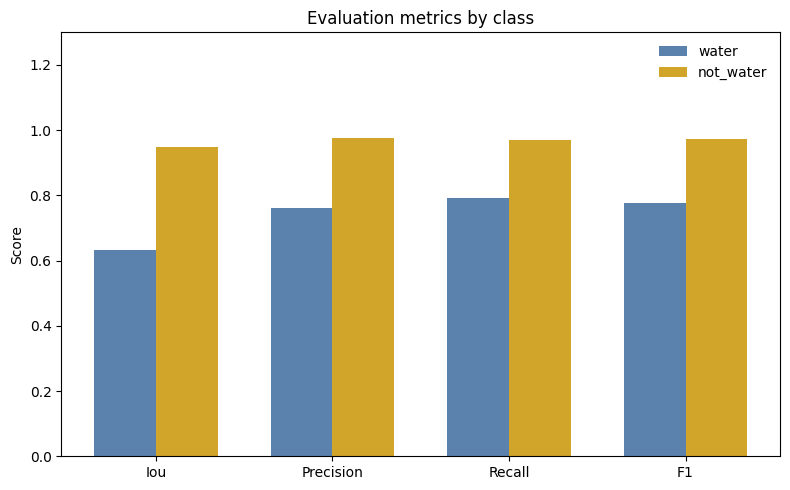

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

classes = ['water', 'not_water']
metric_names = ['iou', 'precision', 'recall', 'f1']
x = np.arange(len(metric_names))
width = 0.35

for i, cls in enumerate(classes):
    values = [metrics[cls][m] for m in metric_names]
    ax.bar(x + i * width, values, width, label=cls, color=colors[i])

ax.set_xticks(x + width / 2)
ax.set_xticklabels([m.capitalize() for m in metric_names])
ax.set_ylim(0, 1.3)
ax.set_ylabel('Score')
ax.set_title('Evaluation metrics by class')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 4. Visual Inspection

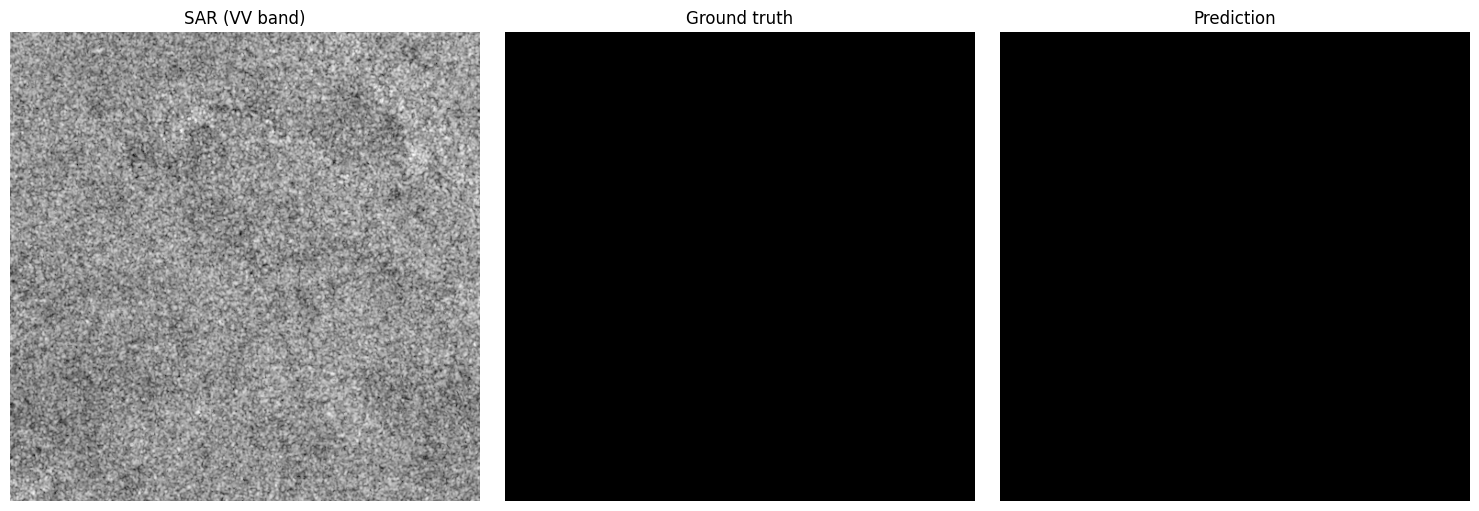

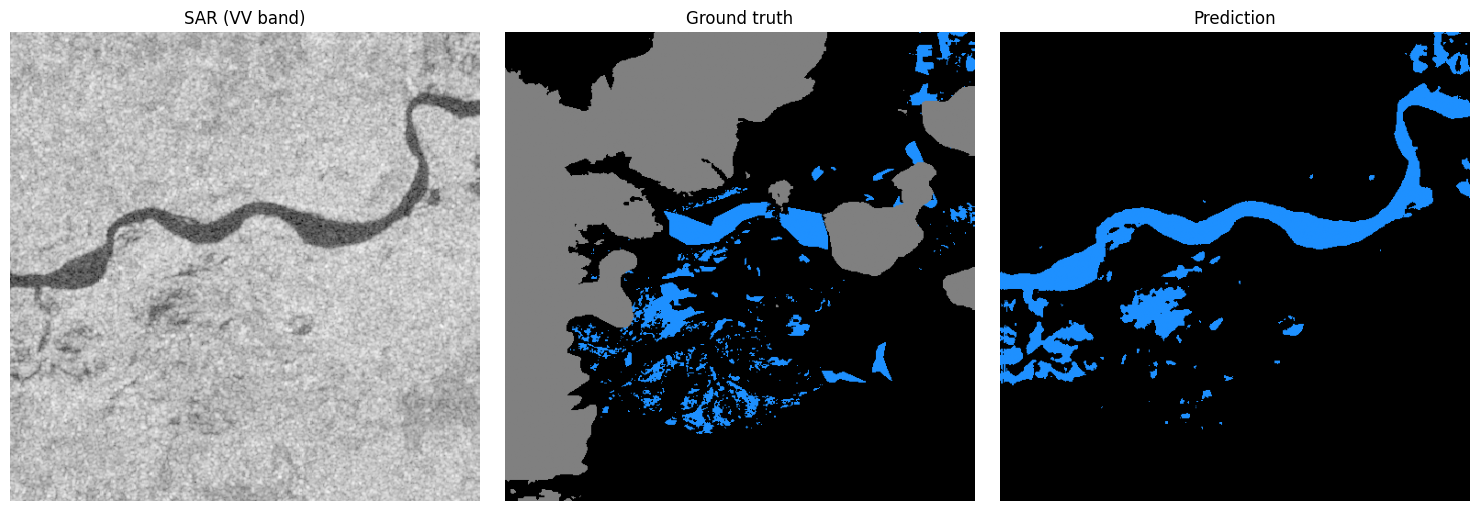

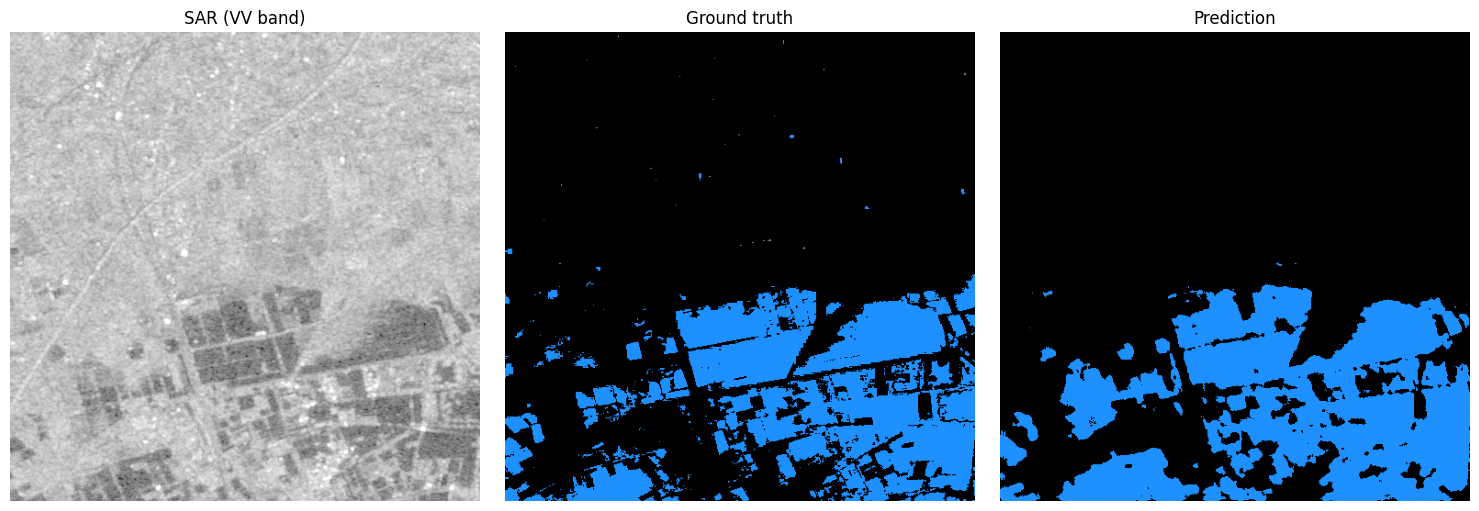

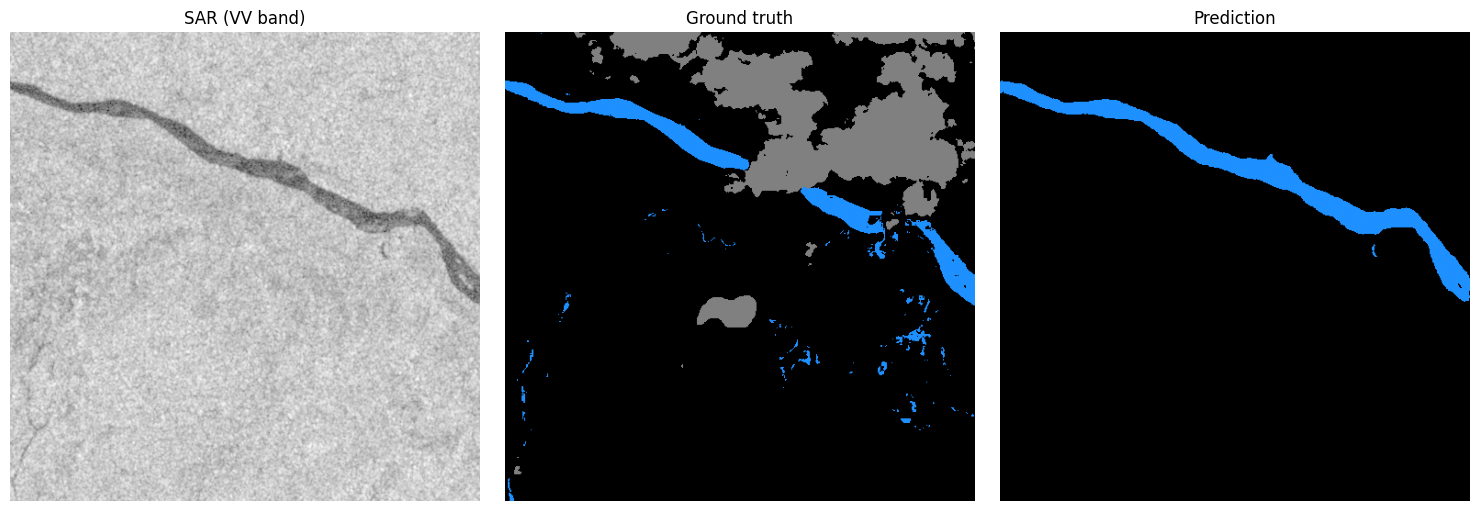

In [6]:
def show_prediction(idx):
    image, label = val_ds[idx]
    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

    vv = image[0].numpy()
    label_np = label.numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(vv, cmap='gray')
    axes[0].set_title('SAR (VV band)')
    axes[0].axis('off')

    cmap = plt.cm.colors.ListedColormap(['gray', 'black', 'dodgerblue'])
    bounds = [-1.5, -0.5, 0.5, 1.5]
    norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)
    axes[1].imshow(label_np, cmap=cmap, norm=norm)
    axes[1].set_title('Ground truth')
    axes[1].axis('off')

    pred_cmap = plt.cm.colors.ListedColormap(['black', 'dodgerblue'])
    pred_norm = plt.cm.colors.BoundaryNorm([-0.5, 0.5, 1.5], pred_cmap.N)
    axes[2].imshow(pred, cmap=pred_cmap, norm=pred_norm)
    axes[2].set_title('Prediction')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

example_indices = np.linspace(0, len(val_ds) - 1, 4, dtype=int)
for idx in example_indices:
    show_prediction(int(idx))

## 5. Key Takeaways

- **Mean IoU: 0.79** (Water: 0.63, Not-water: 0.95), a strong result for SAR-based flood segmentation, consistent with published benchmarks on this dataset.
- The **model performs very well on large, contiguous water bodies with strong contrast against land**, e.g. the main river channels in examples 2 and 4, though it consistently **under-detects smaller, fragmented water patches** even within these otherwise strong predictions.
- **Performance drops further on diffuse, mixed flooding in urban/agricultural areas** (see example 3), where flood boundaries are irregular and partially obscured by structures.
- This **pattern is consistent with a known limitation of U-Net-style architectures**: repeated downsampling in the encoder loses fine spatial detail, making small or fragmented objects harder to segment accurately than large contiguous ones.
- **Water recall (0.79) exceeds precision (0.76) only marginally**; the model does not show a strong bias toward missing floods over false-alarming, which is the safer failure mode for this application.